In [3]:

!pip install icecream

In [9]:
import numpy as np
from math import sin, cos, sqrt

class Kinematic:
    #theta1 -> Base rotation
    #theta2, theta3 -> Two joints adjacents to the base rotation
    #theta4 -> Hand joint
    def __init__(self, l1, l2, l3):
        #init the size of the joints
        self.l1 = l1
        self.l2 = l2
        self.l3 = l3

    #TASK SPACE -> JOINTS SPACE
    def IK(self, p : np.ndarray) -> np.ndarray:
        """
        Receives a position in task space and returns the joint angles to reach that position \n
        Input: p = [x, y, z, fi] (fi is the angle of the hand with the horizontal plane) \n
        Output: q = [theta1, theta2, theta3, theta4] \n
        """

        assert len(p) == 4

        x, y, z, fi = p
        fi = np.deg2rad(fi) #FI IS RECIEVED IN DEGRESS


        #rotate in the z axis
        theta1 = np.arctan2(y,x)

        comprimento = (x**2 + y**2)**0.5

        arccos_factor_numerator = (comprimento-self.l3*cos(fi))**2 + (z-self.l3*sin(fi))**2 - self.l1**2 - self.l2**2
        arccos_factor_denominator = 2*self.l1*self.l2
        if(abs(arccos_factor_numerator/arccos_factor_denominator) > 1):
          theta3 = 0
          if abs(arccos_factor_numerator/arccos_factor_denominator) > 1.1:
            print("the value supposed to be in arccos is big, so the values are not gonna match")
        else:
          theta3 = -np.arccos(arccos_factor_numerator/arccos_factor_denominator) # choose the negative theta3 angle instead of the positive one


        #Theta 2 in function of theta3.
        arctan_factor1 = (z - self.l3*sin(fi))/(comprimento - self.l3*cos(fi))
        arctan_factor2 = (self.l2*sin(theta3))/(self.l1 + self.l2*cos(theta3))
        theta2 = np.arctan(arctan_factor1) - np.arctan(arctan_factor2)



        #Hand rotate
        theta4 = fi - theta2 - theta3

        return np.rad2deg(np.array([theta1, theta2, theta3, theta4])) #RETURN IN DEGRESS

    #JOINTS SPACE -> TASK SPACE
    def FK(self, q: np.ndarray) -> np.ndarray:
        """
        Receives a position in joint space and returns the position in task space \n
        Input: q = [theta1, theta2, theta3, theta4] (fi is the angle of the hand with the horizontal plane) \n
        Output: p = [x, y, z, fi] (fi is the angle of the hand with the horizontal plane) \n
        """
        q = np.deg2rad(q) #Q IS RECEIVED IN DEGREE
        # solving for Z
        theta1, theta2, theta3, theta4 = q
        z = self.l1*sin(theta2) + self.l2*sin(theta2+theta3) + self.l3*sin(theta2+theta3+theta4)

        # solving for X and Y
        comprimento = self.l1*cos(theta2) + self.l2*cos(theta2+theta3) + self.l3*cos(theta2+theta3+theta4)
        x = comprimento * cos(theta1)
        y = comprimento * sin(theta1)

        phi = theta2+theta3+theta4
        phi = np.rad2deg(phi) #PHI IS IN DEGREE
        return np.array([x,y,z,phi])


class TrajectoryPlanner:
    def __init__(self, vel_max_joint : float, aceleration_max_joint : float,
                 l1, l2 , l3, frequency = 50, current_position_joint = np.array([0, 90, -90, 0])):


        self.vel_max_joint = vel_max_joint
        self.aceleration_max_joint = aceleration_max_joint
        self.current_position_joint = current_position_joint

        self.frequency = frequency
        self.kin = Kinematic(l1, l2, l3)

        #The position is [l2 + l3, 0, l1, 0] by default because the model
        self.current_position_task = self.kin.FK(current_position_joint)
        self.vel_max_task = vel_max_joint/10
        self.aceleration_max_task = aceleration_max_joint/5 # Just to test!

    # plan only a single joint
    def planning_single_trajectory(self, initial_position: float, final_position: float, velocity_value : float, aceleration_value : float) -> np.ndarray:
        """
        Returns a trajectory of a single joint
        Input: initial_position = initial angle of the joint
               final_position = final angle of the joint
        Output: positions = trajectory of a single joint
        """

        distance = final_position - initial_position # delta s
        forward = 1 if (distance >= 0) else -1  #direction of movement(+1 if distance positive, -1 if negative)

        time_in_aceleration = velocity_value / aceleration_value #t = v / a
        distance_in_aceleration = aceleration_value*(time_in_aceleration**2)/2 # S = at**2/2
        time_in_deceleration = time_in_aceleration # t = v / a
        distance_in_deceleration = velocity_value*time_in_deceleration + -1*aceleration_value*(time_in_deceleration**2)/2 # S = Vo*t - at**2/2

        if distance_in_aceleration + distance_in_deceleration < distance:
            gap_distance = distance - distance_in_aceleration - distance_in_deceleration
            time_in_vel_cte = gap_distance / velocity_value
        elif distance_in_aceleration + distance_in_deceleration == distance:
            time_in_vel_cte = 0
        elif distance_in_aceleration + distance_in_deceleration > distance:
            #d/2 = a(t**2)/2 so t = sqrt(d/a)
            time_in_aceleration = sqrt(abs(distance)/aceleration_value)
            time_in_deceleration = time_in_aceleration
            time_in_vel_cte = 0


        total_time = time_in_aceleration + time_in_vel_cte + time_in_deceleration

        #convert the aceleration from seconds to slices

        slices = int(total_time * self.frequency) + 1

        #init the vectors
        positions = np.zeros(slices)
        positions[0] = initial_position
        speeds = np.zeros(slices)
        acelerations = np.zeros(slices)

        # get amount of samples for aceleration and deceleration
        slices_in_aceleration = int(time_in_aceleration * self.frequency) + 1
        slices_in_deceleration = int(time_in_deceleration * self.frequency)

        # update the acelerations array with the aceleration and deceleration values
        acelerations[:slices_in_aceleration] = forward*aceleration_value
        acelerations[-slices_in_deceleration:] = -1*forward*aceleration_value

        dt = 1 / self.frequency
        for i in range(1, slices):
            speeds[i] = speeds[i-1] + acelerations[i]*dt
            positions[i] = positions[i-1] + speeds[i]*dt
        print(f"{positions[-1]}, {final_position}")
        return positions

    @staticmethod
    def repeat_position(vector : np.ndarray, size_aim : int):
        extra_array = np.ones(size_aim - len(vector))*vector[-1]
        vector = np.concatenate((vector, extra_array))
        return vector

    def vectorized_IK(self, vector_x, vector_y, vector_z, vector_fi):
        assert len(vector_x) == len(vector_y) == len(vector_z) == len(vector_fi)
        size = len(vector_x)
        planning_q1 = np.empty(size)
        planning_q2 = np.empty(size)
        planning_q3 = np.empty(size)
        planning_q4 = np.empty(size)


        for i in range(size):
            x, y, z, fi = vector_x[i], vector_y[i], vector_z[i], vector_fi[i]
            q1, q2, q3, q4 = self.kin.IK(np.array([x, y, z, fi], dtype=np.float32))
            planning_q1[i] = q1
            planning_q2[i] = q2
            planning_q3[i] = q3
            planning_q4[i] = q4

        return (planning_q1, planning_q2, planning_q3, planning_q4)

    def vectorized_FK(self, vector_q1, vector_q2, vector_q3, vector_q4):
        assert len(vector_q1) == len(vector_q2) == len(vector_q3) == len(vector_q4)
        size = len(vector_q1)
        planning_x = np.empty(size)
        planning_y = np.empty(size)
        planning_z = np.empty(size)
        planning_fi = np.empty(size)


        for i in range(size):
            q1, q2, q3, q4 = vector_q1[i], vector_q2[i], vector_q3[i], vector_q4[i]
            x, y, z, fi = self.kin.IK(np.array([q1, q2, q3, q4], dtype=np.float32))
            planning_x[i] = x
            planning_y[i] = y
            planning_z[i] = z
            planning_fi[i] = fi

        return (planning_x, planning_y, planning_z, planning_fi)

    # plan the trajectory from the current position to the target position in joint space
    def move(self, target_position: np.ndarray, updateCurrPos: bool = True, mode: str = "joint") -> np.ndarray:
        """
        Returns a trajectory of the arm from the current position to the target position in joint space \n
        Input: target_position_task = [x, y, z, fi], fi in DEGRESS \n
        Output: trajectory = Each row = [theta1, theta2, theta3, theta4] in DEGRESS
        """


        # get target position in joints space
        if mode == "joint":
            target_position = self.kin.IK(target_position)
            current_position = self.current_position_joint
            v = self.vel_max_joint
            a = self.aceleration_max_joint
        # get target position in task space
        elif mode == "task":
            target_position = target_position
            current_position = self.current_position_task
            v = self.vel_max_task
            a = self.vel_max_joint
            self.frequency = 2*self.frequency

        else:
            raise ValueError("Wrong mode")

        # get the trajectory for each joint
        planning_target1 = self.planning_single_trajectory(current_position[0], target_position[0], v, a)
        planning_target2 = self.planning_single_trajectory(current_position[1], target_position[1], v, a)
        planning_target3 = self.planning_single_trajectory(current_position[2], target_position[2], v, a)
        planning_target4 = self.planning_single_trajectory(current_position[3], target_position[3], v, a)





        # get the legth of the trajectory that takes more time to finish the movement
        max_len = max(len(planning_target1), len(planning_target2), len(planning_target3), len(planning_target4))

        #filling gaps with the last position of each joint to make all joints have the same length
        planning_target1 = self.repeat_position(planning_target1, max_len)
        planning_target2 = self.repeat_position(planning_target2, max_len)
        planning_target3 = self.repeat_position(planning_target3, max_len)
        planning_target4 = self.repeat_position(planning_target4, max_len)

        if mode == "task":
            results = self.vectorized_IK(planning_target1, planning_target2, planning_target3, planning_target4)
            planning_target1, planning_target2, planning_target3, planning_target4 = results
            self.frequency = self.frequency/2




        # update the current position of the arm
        if updateCurrPos:
            final = [planning_target1[-1], planning_target2[-1], planning_target3[-1], planning_target4[-1]]
            self.current_position_joint = np.array(final)
            self.current_position_task = self.kin.FK(self.current_position_joint)
            print(f"NOW THE CURRENT JOINTS CORDINATES IS {self.current_position_joint}")
            print(f"NOW THE CURRENT TASK CORDINATES IS {self.current_position_task}")



        return np.stack([planning_target1, planning_target2, planning_target3, planning_target4], axis=1)

In [10]:
L1 = 10.3
L2 = 12.28
L3 = 5.2
MAX_JOINT_VELOCITY = 60 # degrees/s
MAX_JOINT_ACCELERATION = 30 # degrees/s²

# Validate Planning at joint space and task space


In [14]:
target = np.array([10, 10, 10, 0], dtype = np.float32)


Planner = TrajectoryPlanner(MAX_JOINT_VELOCITY, MAX_JOINT_ACCELERATION, L1, L2, L3)
planning_at_joint = Planner.move(target, mode = "joint")


Planner = TrajectoryPlanner(MAX_JOINT_VELOCITY, MAX_JOINT_ACCELERATION, L1, L2, L3, frequency = 1000)
planning_at_task =Planner.move(target, mode = "task")

44.65200000000003, 45.00000125223908
108.72000000000003, 108.89334666338003
-107.32800000000002, -107.70379819163786
-1.08, -1.1895484717421694
NOW THE CURRENT JOINTS CORDINATES IS [  44.652  108.72  -107.328   -1.08 ]
NOW THE CURRENT TASK CORDINATES IS [10.08078749  9.95906899 10.08174167  0.312     ]
10.00346000000002, 10.0
9.999000000000331, 10.0
10.001784999999998, 10.0
0.0, 0.0
NOW THE CURRENT JOINTS CORDINATES IS [  44.98722197  108.88297247 -107.68791117   -1.1950613 ]
NOW THE CURRENT TASK CORDINATES IS [ 1.00034606e+01  9.99899967e+00  1.00017849e+01 -1.27222187e-14]


Text(0.5, 0.98, 'JOINT TRAJECTORY, TRAJECTORY CALCULED AT JOINT SPACE')

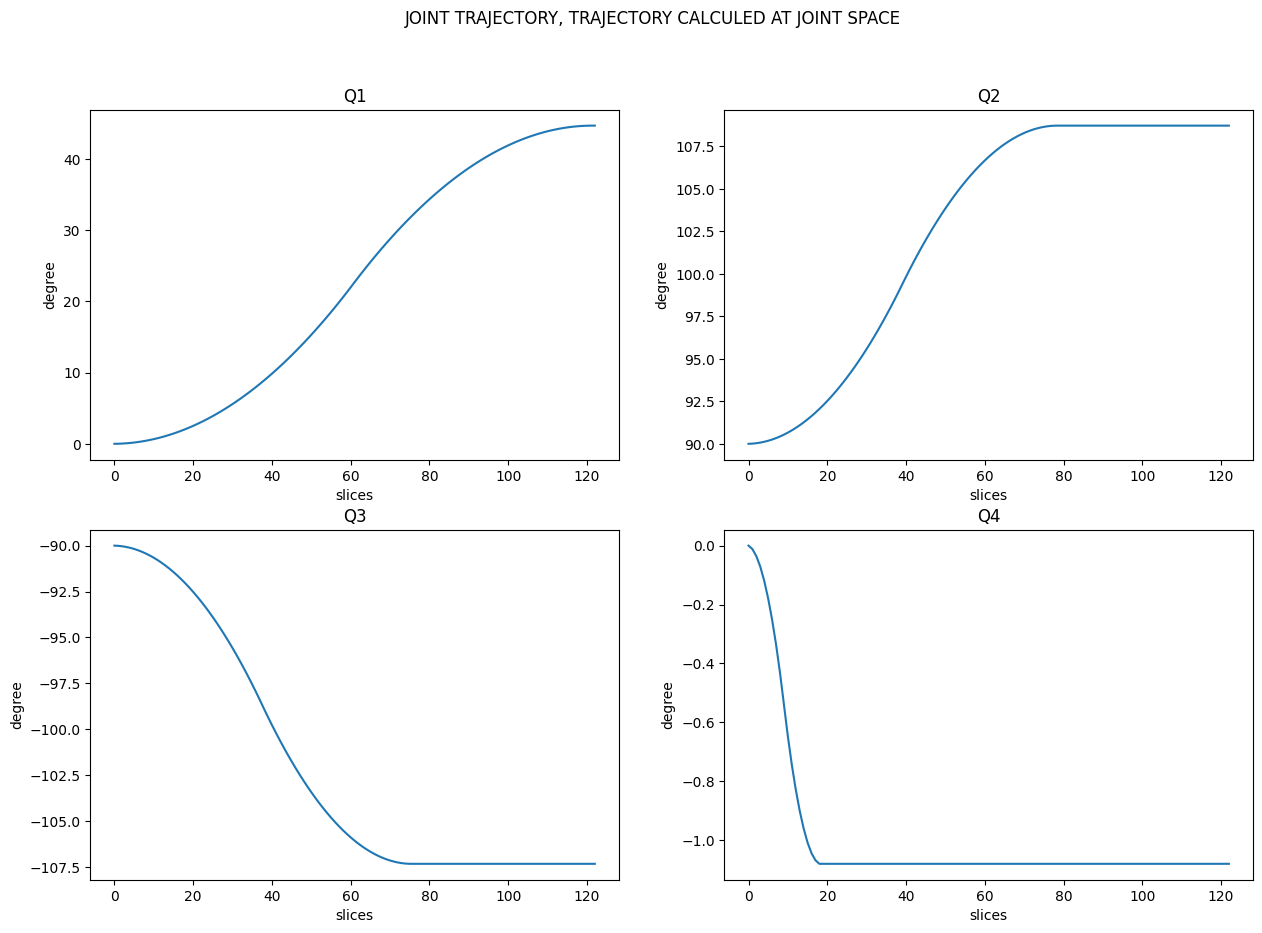

In [15]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0][0]
ax.plot(planning_at_joint[:,0])
ax.set_title("Q1")
ax.set_xlabel("slices")
ax.set_ylabel("degree")

ax = axes[0][1]
ax.plot(planning_at_joint[:,1])
ax.set_title("Q2")
ax.set_xlabel("slices")
ax.set_ylabel("degree")


ax = axes[1][0]
ax.plot(planning_at_joint[:,2])
ax.set_title("Q3")
ax.set_xlabel("slices")
ax.set_ylabel("degree")


ax = axes[1][1]

ax.plot(planning_at_joint[:,3])
ax.set_title("Q4")
ax.set_xlabel("slices")
ax.set_ylabel("degree")

plt.suptitle("JOINT TRAJECTORY, TRAJECTORY CALCULED AT JOINT SPACE")



Text(0.5, 0.98, 'JOINT TRAJECTORY, TRAJECTORY CALCULED AT TASK SPACE')

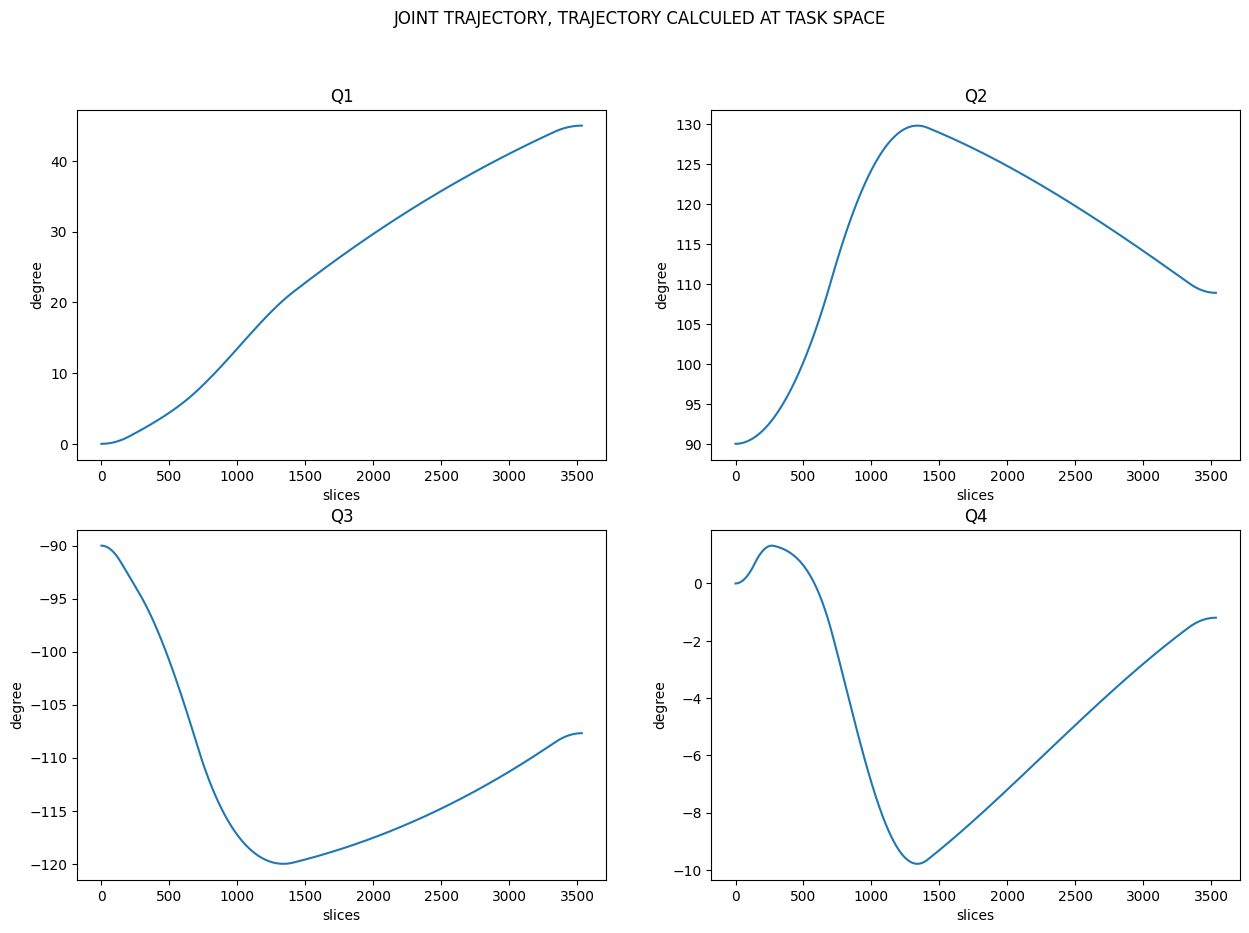

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0][0]
ax.plot(planning_at_task[:,0])
ax.set_title("Q1")
ax.set_xlabel("slices")
ax.set_ylabel("degree")

ax = axes[0][1]
ax.plot(planning_at_task[:,1])
ax.set_title("Q2")
ax.set_xlabel("slices")
ax.set_ylabel("degree")


ax = axes[1][0]
ax.plot(planning_at_task[:,2])
ax.set_title("Q3")
ax.set_xlabel("slices")
ax.set_ylabel("degree")


ax = axes[1][1]

ax.plot(planning_at_task[:,3])
ax.set_title("Q4")
ax.set_xlabel("slices")
ax.set_ylabel("degree")

plt.suptitle("JOINT TRAJECTORY, TRAJECTORY CALCULED AT TASK SPACE")

# Validate Planning at joint space and task space


the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match

Text(0.5, 0.98, 'TASK TRAJECTORY, TRAJECTORY CALCULED AT JOINT SPACE')

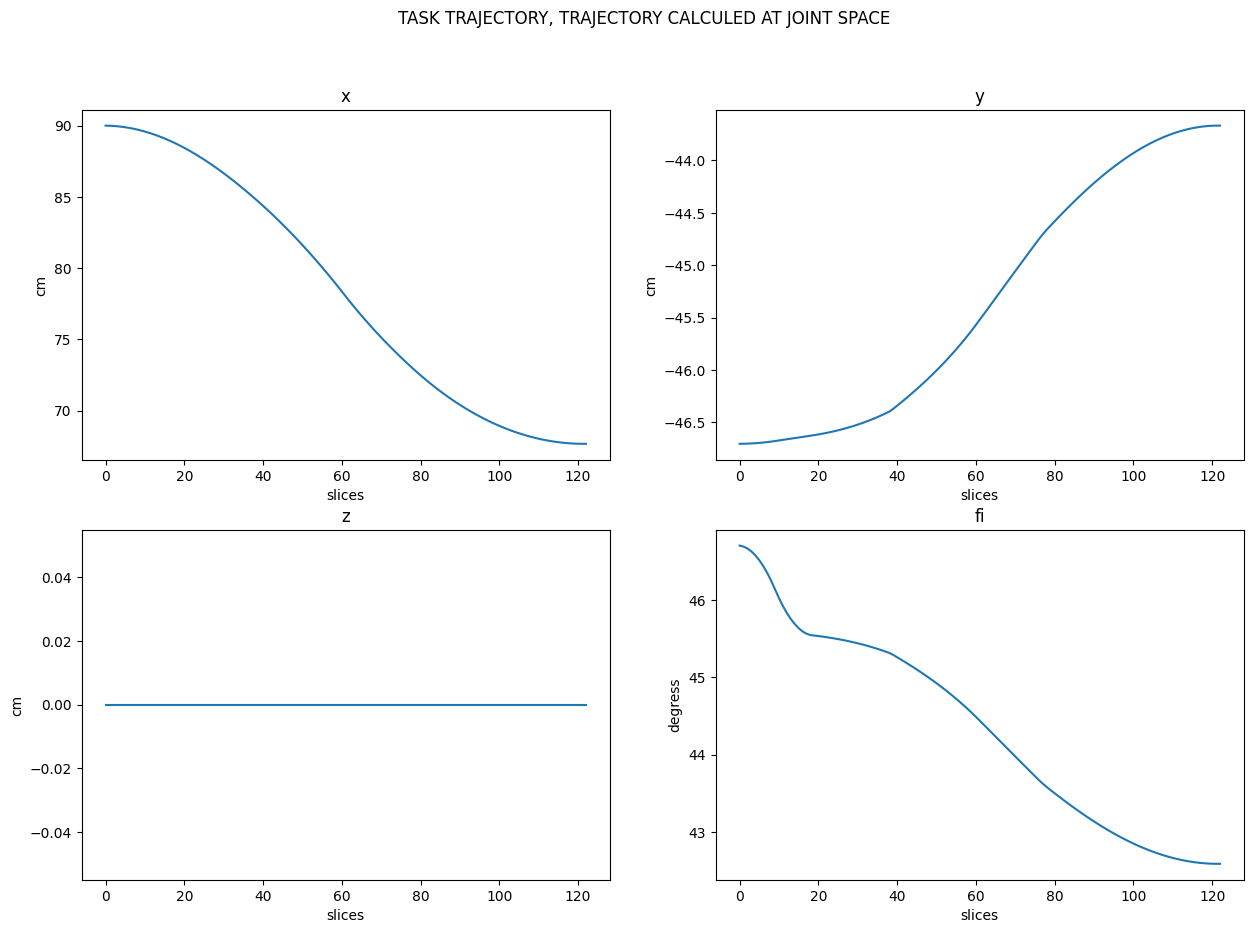

In [18]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plan_x, plan_y, plan_z, plan_fi = Planner.vectorized_FK(planning_at_joint[:, 0], planning_at_joint[:, 1], planning_at_joint[:, 2], planning_at_joint[:, 3])
print(plan_x.shape)


ax = axes[0][0]
ax.plot(plan_x)
ax.set_title("x")
ax.set_xlabel("slices")
ax.set_ylabel("cm")


ax = axes[0][1]
ax.plot(plan_y)
ax.set_title("y")
ax.set_xlabel("slices")
ax.set_ylabel("cm")


ax = axes[1][0]
ax.plot(plan_z)
ax.set_title("z")
ax.set_xlabel("slices")
ax.set_ylabel("cm")


ax = axes[1][1]
ax.plot(plan_fi)
ax.set_title("fi")
ax.set_xlabel("slices")
ax.set_ylabel("degress")

plt.suptitle("TASK TRAJECTORY, TRAJECTORY CALCULED AT JOINT SPACE")



the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match
the value supposed to be in arccos is big, so the values are not gonna match

Text(0.5, 0.98, 'TASK TRAJECTORY, TRAJECTORY CALCULED AT JOINT SPACE')

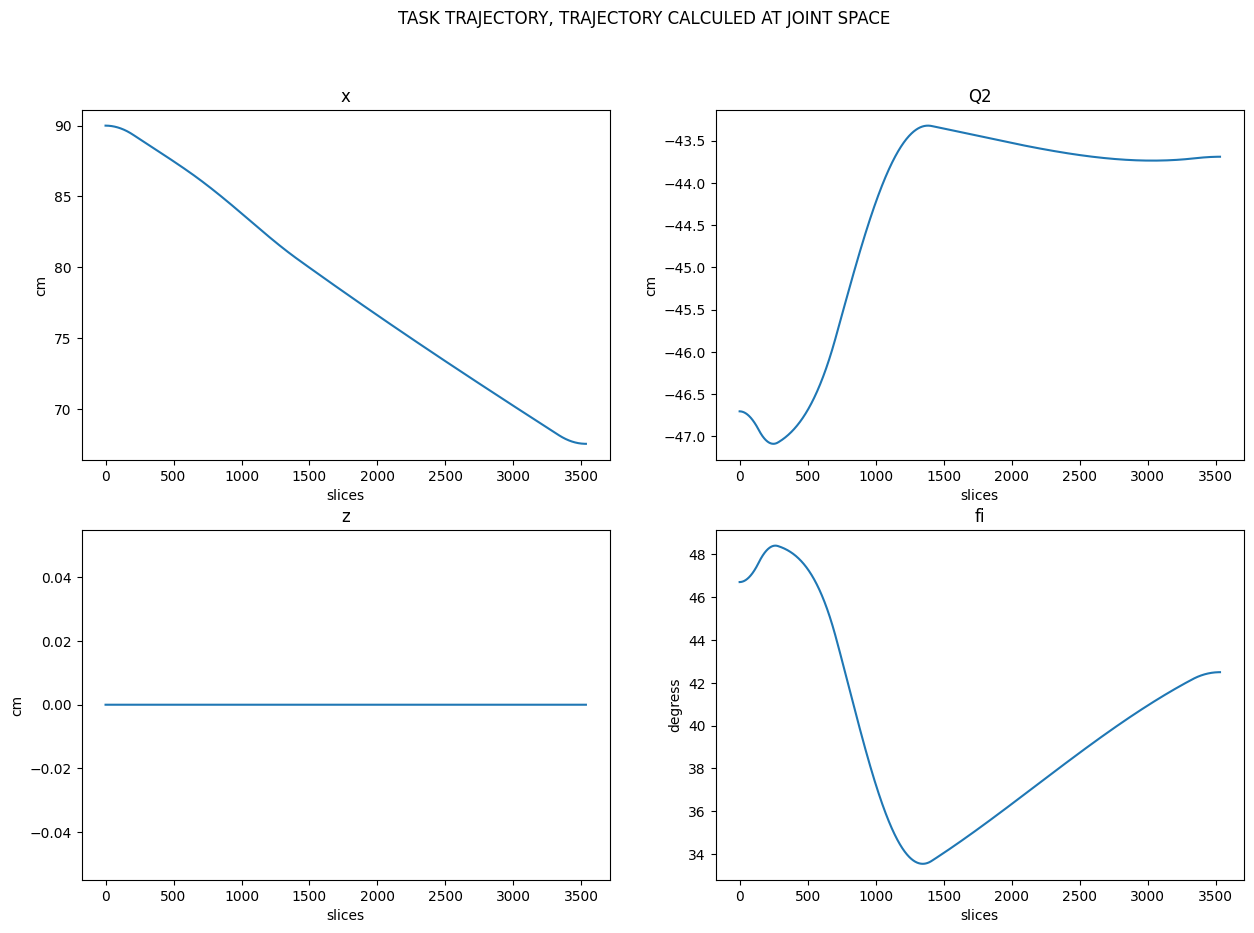

In [19]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plan_x, plan_y, plan_z, plan_fi = Planner.vectorized_FK(planning_at_task[:, 0], planning_at_task[:, 1], planning_at_task[:, 2], planning_at_task[:, 3])
print(plan_x.shape)


ax = axes[0][0]
ax.plot(plan_x)
ax.set_title("x")
ax.set_xlabel("slices")
ax.set_ylabel("cm")


ax = axes[0][1]
ax.plot(plan_y)
ax.set_title("Q2")
ax.set_xlabel("slices")
ax.set_ylabel("cm")


ax = axes[1][0]
ax.plot(plan_z)
ax.set_title("z")
ax.set_xlabel("slices")
ax.set_ylabel("cm")


ax = axes[1][1]
ax.plot(plan_fi)
ax.set_title("fi")
ax.set_xlabel("slices")
ax.set_ylabel("degress")

plt.suptitle("TASK TRAJECTORY, TRAJECTORY CALCULED AT JOINT SPACE")



# Validate FK and IK

joint space from IK:  [ 55.30484647  51.5362442  -67.97568716 -73.56055703]
back to task space, should be equal to yout input:  [ 9.0000000e+00  1.3000000e+01 -8.8817842e-16 -9.0000000e+01]


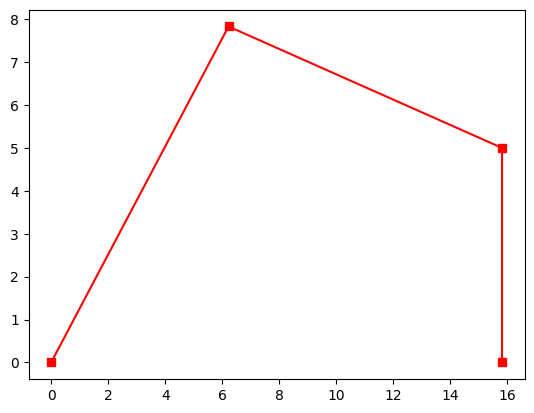

In [ ]:
#import matplotlib.pyplot as plt
#import numpy as np
#from math import cos, sin
kin = Kinematic(10,10,5)
p = np.array([9,13,0,-90]) # insert your position here
q = kin.IK(p)
print("joint space from IK: " ,q)
print("back to task space, should be equal to yout input: ", kin.FK(q))
q = np.deg2rad(q)
horizontalPlot = [0,kin.l1*cos(q[1]), kin.l1*cos(q[1]) + kin.l2*cos(q[1] + q[2]), kin.l1*cos(q[1]) + kin.l2*cos(q[1] + q[2]) + kin.l3*cos(q[1] + q[2] + q[3])]
verticalPlot = [0,kin.l1*sin(q[1]), kin.l1*sin(q[1]) + kin.l2*sin(q[1] + q[2]), kin.l1*sin(q[1]) + kin.l2*sin(q[1] + q[2]) + kin.l3*sin(q[1] + q[2] + q[3])]

plt.plot(horizontalPlot, verticalPlot, 'rs')
plt.plot(horizontalPlot, verticalPlot, 'r-')
plt.show()
